In [2]:
import scanpy as sc
import pandas as pd
adata = sc.read_h5ad("baseline_clustered.h5ad")

In [3]:
#checking to see its worked

adata
adata.raw.shape

(5926, 55737)

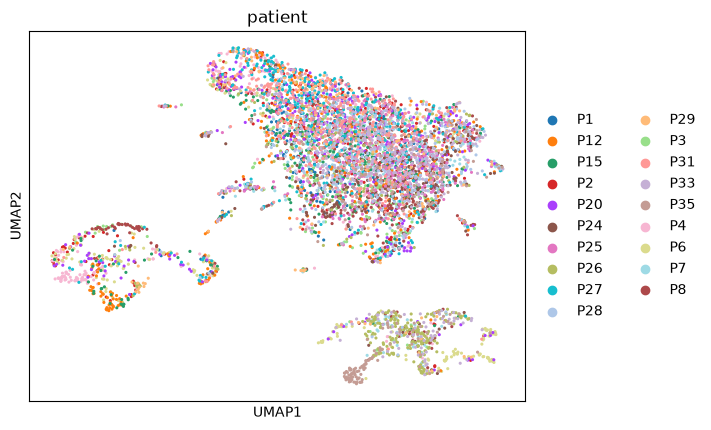

leiden_0.4
11    0.983607
10    0.331010
6     0.228438
8     0.207317
12    0.176471
4     0.166667
9     0.152174
5     0.136986
13    0.125000
0     0.122507
7     0.120482
3     0.119593
2     0.116531
1     0.115875
dtype: float64

In [4]:
#checking if we need to batch correct.
#they mix very well so this is a good sign that we do not need to batch correct.
#if we needed to we would have seen clusters of cells that are made up of only one patient.

sc.pl.umap(adata, color="patient")

ct = pd.crosstab(adata.obs["leiden_0.4"], adata.obs["patient"], normalize="index")
ct.max(axis=1).sort_values(ascending=False)

In [5]:
#we don't want to use Harmony (batch correction) because this would hide what is going on with cluser 11. 
#like we said before, cluster 11 is almost entirely made up of one patient. 
# If we batch correct, we would be hiding this fact.


ct = pd.crosstab(adata.obs["leiden_0.4"], adata.obs["patient"], normalize="index")
ct.max(axis=1).sort_values(ascending=False)

leiden_0.4
11    0.983607
10    0.331010
6     0.228438
8     0.207317
12    0.176471
4     0.166667
9     0.152174
5     0.136986
13    0.125000
0     0.122507
7     0.120482
3     0.119593
2     0.116531
1     0.115875
dtype: float64

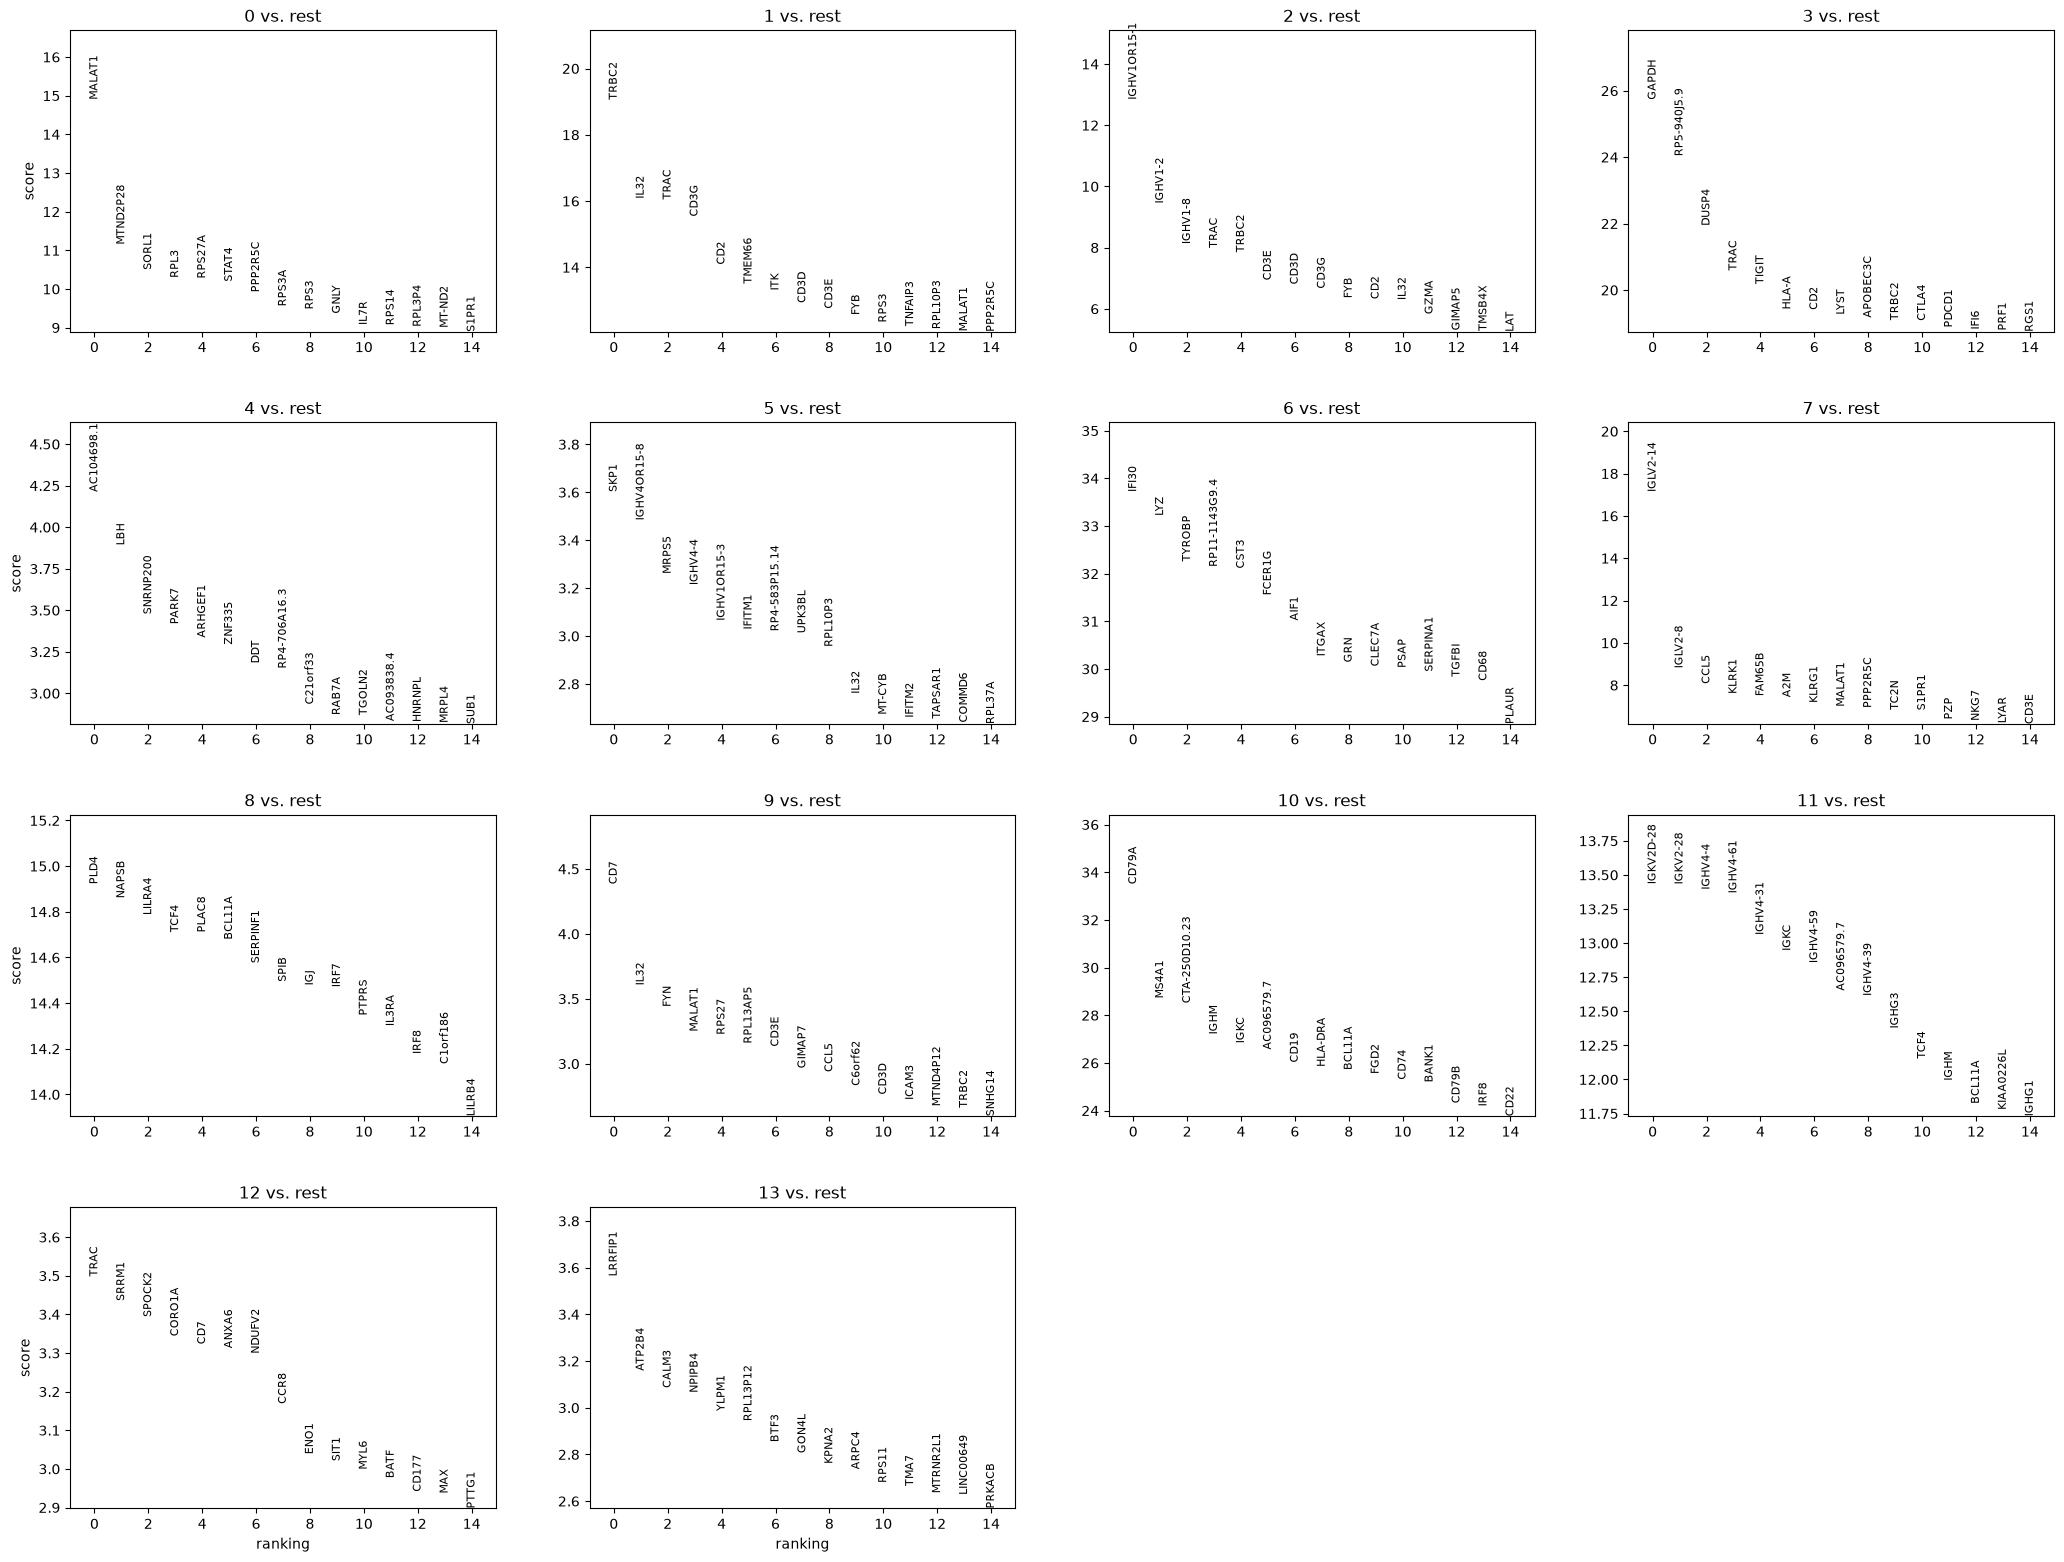

In [6]:
#finding each clusters gene marker 
#cluster 11 is an immunoglobulin - therefore we do not need to remove it because its not a specific cell specialisation, just antibodies from B cells.
 

sc.tl.rank_genes_groups(adata, "leiden_0.4", method="wilcoxon")

sc.pl.rank_genes_groups(adata, n_genes=15, sharey=False)

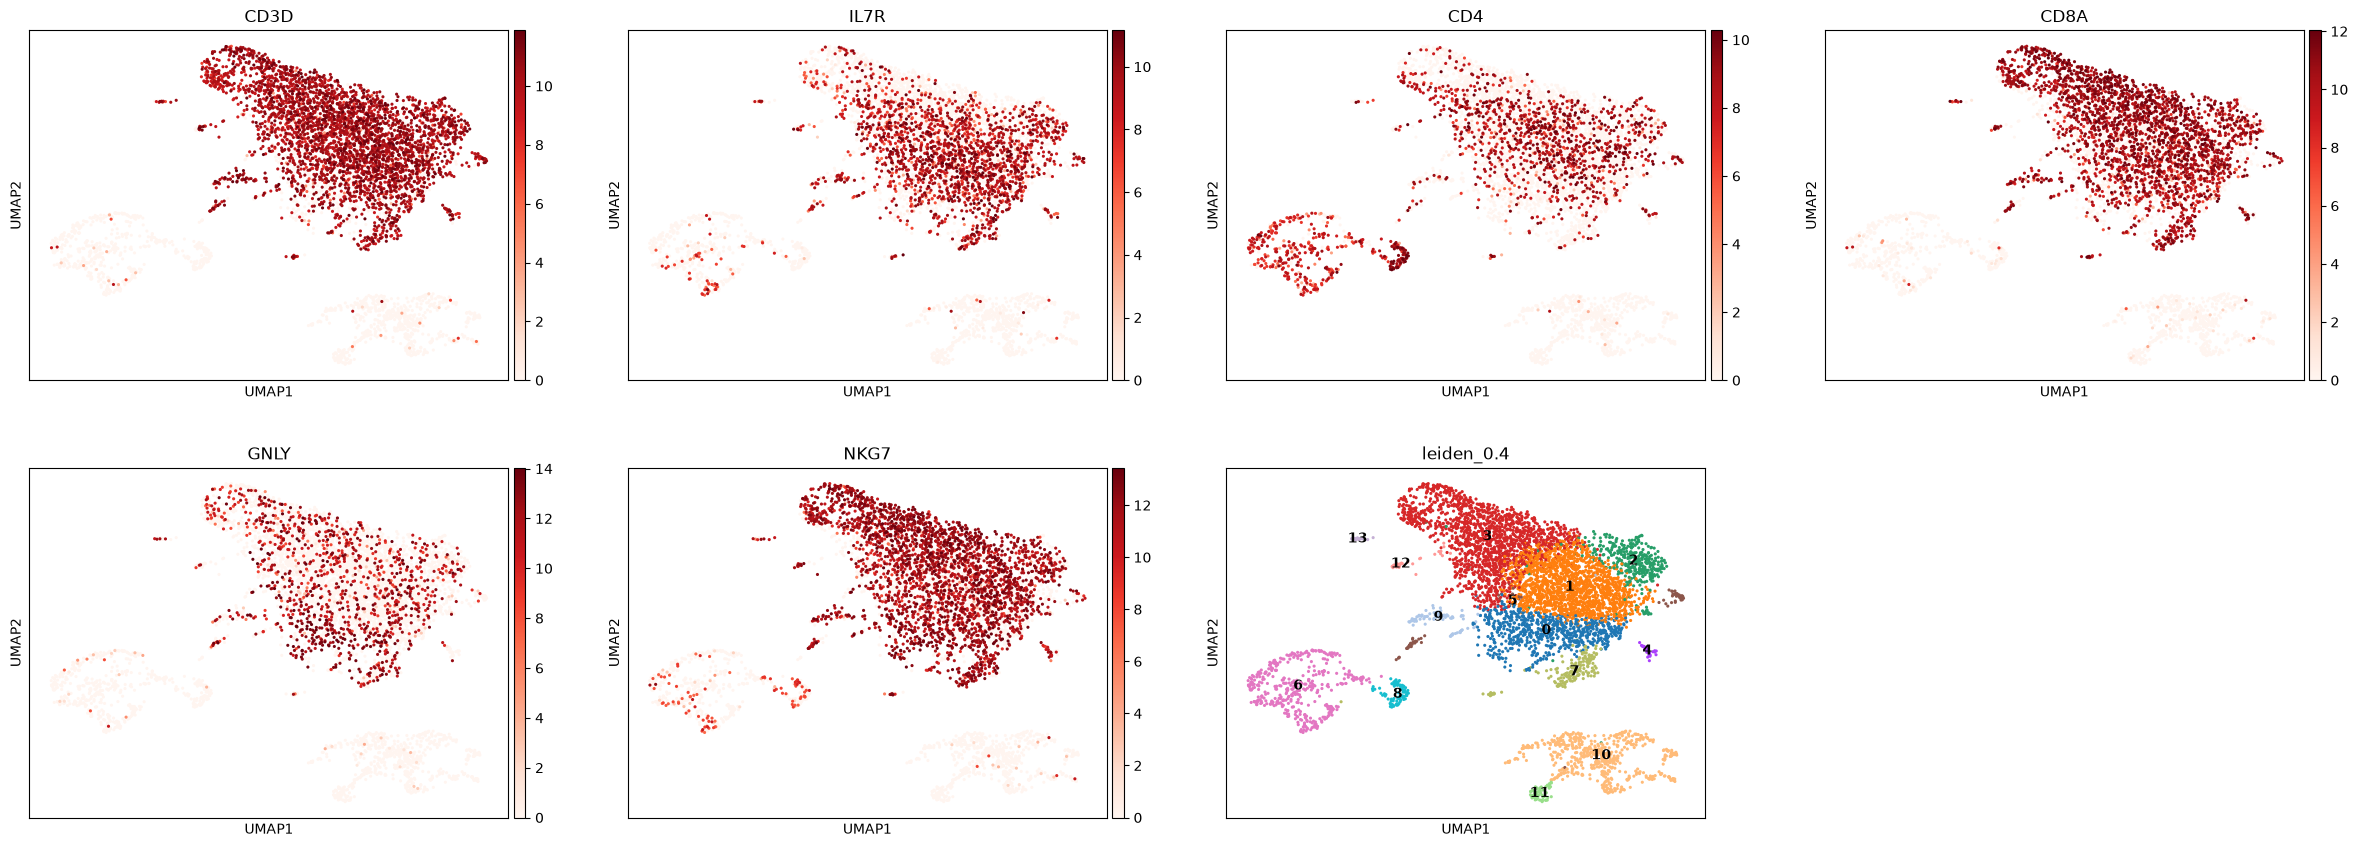

In [7]:
#cluster 0 points towards naive or memeory T-cell population becuase of IL7R and S1PR1 expression
#but there is also a small population of NK cells in this cluster because of NKG7 and GNLY expression.

#this is code that claude gave that should test this hypothesis. 

#CD3D - the entire central mass is dark red, including cluster 0. 
#Both islands are white so everything in the main mass is T cell, and the islands are not.

#the GNLY plot is not dense in the main mass so i think it is a red herring

#CD8A - the main mass is dark red, but the islands are white.
#so the islands are not CD8 T cells, but the main mass is.

#in conclusion, i believe cluster 0 is a CD8 T-cell population but its not a pure population


sc.pl.umap(adata, color=["CD3D", "IL7R", "CD4", "CD8A", "GNLY", "NKG7", "leiden_0.4"],
           use_raw=True, cmap="Reds", vmax="p99", legend_loc="on data")

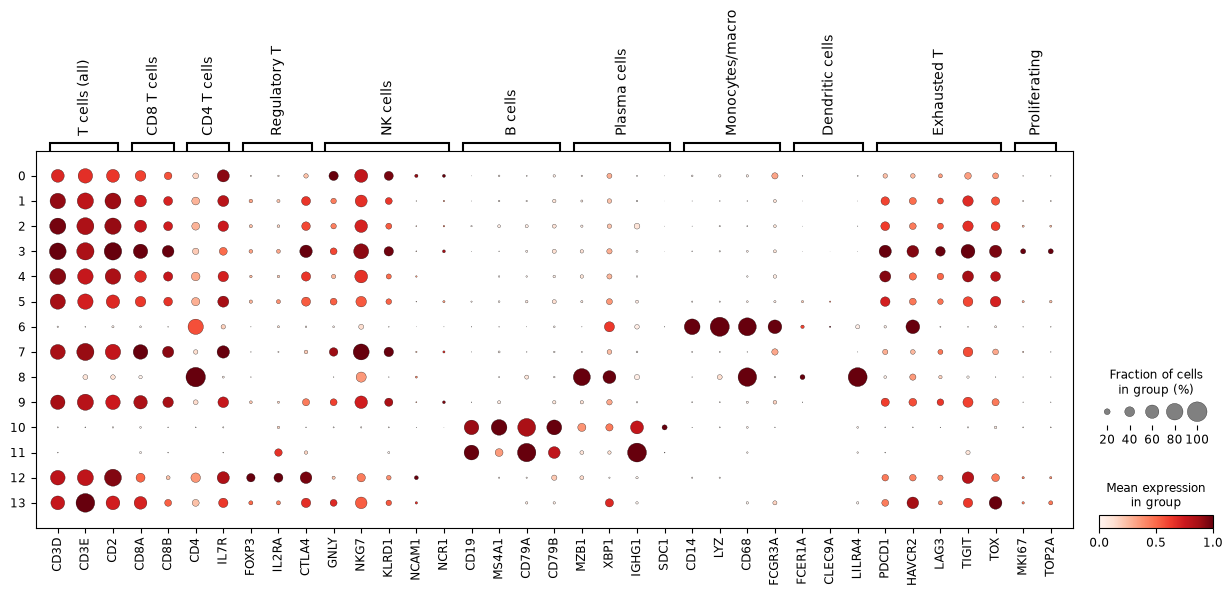

In [8]:
#cluster 1 is likely a T-cell, either CD4 or CD8, 
#but not NK cells because of the lack of GNLY and NKG7 expression.

#claude recommended a dotplot to see if it is CD4 or CD8 T-cells.
#this is like what was done in chapter 13 of the single cell textbook, but with a different set of genes.


marker_genes = {
    "T cells (all)":      ["CD3D", "CD3E", "CD2"],
    "CD8 T cells":        ["CD8A", "CD8B"],
    "CD4 T cells":        ["CD4", "IL7R"],
    "Regulatory T":       ["FOXP3", "IL2RA", "CTLA4"],
    "NK cells":           ["GNLY", "NKG7", "KLRD1", "NCAM1", "NCR1"],
    "B cells":            ["CD19", "MS4A1", "CD79A", "CD79B"],
    "Plasma cells":       ["MZB1", "XBP1", "IGHG1", "SDC1"],
    "Monocytes/macro":    ["CD14", "LYZ", "CD68", "FCGR3A"],
    "Dendritic cells":    ["FCER1A", "CLEC9A", "LILRA4"],
    "Exhausted T":        ["PDCD1", "HAVCR2", "LAG3", "TIGIT", "TOX"],
    "Proliferating":      ["MKI67", "TOP2A"],
}

marker_genes_in_data = {
    ct: [g for g in genes if g in adata.raw.var_names]
    for ct, genes in marker_genes.items()
}
marker_genes_in_data

sc.pl.dotplot(adata, marker_genes_in_data, groupby="leiden_0.4",
              standard_scale="var", use_raw=True)

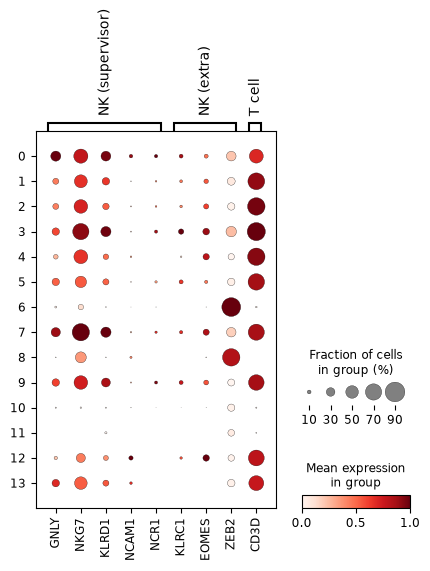

In [9]:
#these are broad markers that PhD student gave me from the lab 

BROAD_MARKERS = {
    "T cell":               ["CD3D", "CD3E", "CD3G", "CD4", "CD8A", "CD8B", "KLRB1", "ZBTB16"],
    "B cell":               ["CD79A", "CD19", "MS4A1", "JCHAIN", "CD38", "MZB1"],
    "NK cell":              ["KLRD1", "KLRC1", "NCAM1", "EOMES", "ZEB2", "IL7R", "ID2", "AREG"],
    "Monocyte/Macrophage":  ["CD68", "LYZ", "CD14"],
    "cDC":                  ["CLEC9A", "FCER1A", "LAMP3"],
    "pDC":                  ["LILRA4", "IL3RA", "PLD4"],
    "Granulocyte":          ["ITGAM", "CEACAM8", "FUT4", "ANPEP", "TPSAB1"],
    "Progenitor/HSC":       ["CD34", "KIT", "SPINK2", "MKI67", "TOP2A"],
}

# this make another dotplot 

nk_check = {
    "NK (supervisor)": ["GNLY", "NKG7", "KLRD1", "NCAM1", "NCR1"],
    "NK (extra)":      ["KLRC1", "EOMES", "ZEB2"],
    "T cell":          ["CD3D"],
}
nk_check = {k: [g for g in v if g in adata.raw.var_names] for k, v in nk_check.items()}

sc.pl.dotplot(adata, nk_check, groupby="leiden_0.4",
              standard_scale="var", use_raw=True)


#i don't like the way this came out so much but i will keep it in mind for the future.

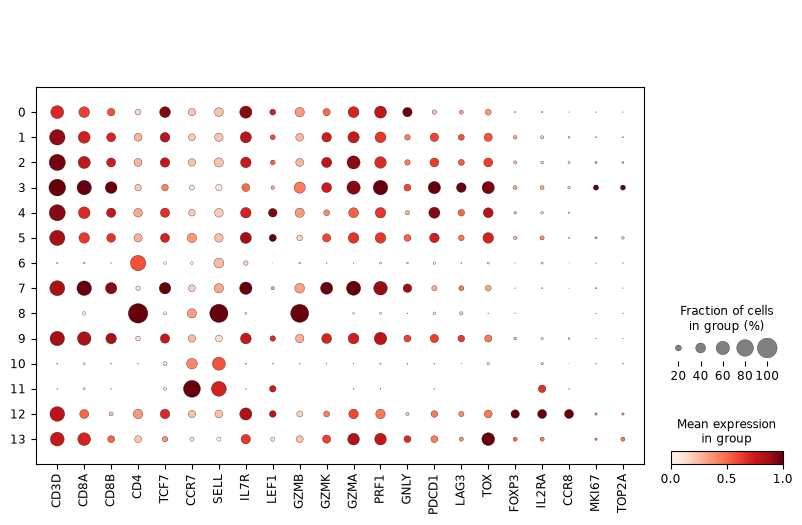

In [10]:
#one more dotplot to see if we can find the T-cell subtypes in the clusters.
#so far i have 5 solid clusters and im trying to figure out the rest.

t_state = ["CD3D", "CD8A", "CD8B", "CD4",
           "TCF7", "CCR7", "SELL", "IL7R", "LEF1",      # naive / memory / stem-like
           "GZMB", "GZMK", "GZMA", "PRF1", "GNLY",       # cytotoxic / effector
           "PDCD1", "LAG3", "TOX",                        # exhausted
           "FOXP3", "IL2RA", "CCR8",                      # Treg
           "MKI67", "TOP2A"]                              # proliferating
t_state = [g for g in t_state if g in adata.raw.var_names]

sc.pl.dotplot(adata, t_state, groupby="leiden_0.4",
              standard_scale="var", use_raw=True)

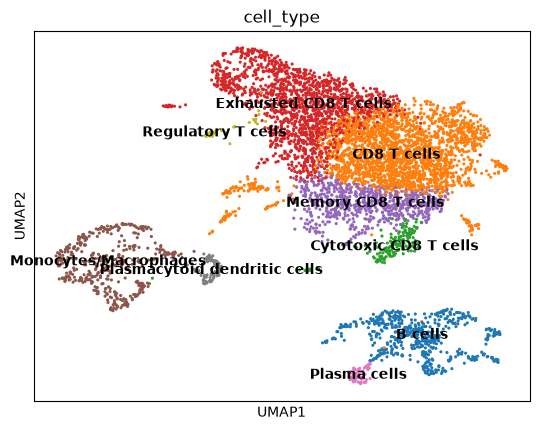

In [11]:
#this is my mapping so far. 
#this is a prediction and i will need to confirm it with CellTypist 

mapping = {
    "0":  "Memory CD8 T cells",
    "1":  "CD8 T cells",
    "2":  "CD8 T cells",
    "3":  "Exhausted CD8 T cells",
    "4":  "CD8 T cells",
    "5":  "CD8 T cells",
    "6":  "Monocytes/Macrophages",
    "7":  "Cytotoxic CD8 T cells",
    "8":  "Plasmacytoid dendritic cells",
    "9":  "CD8 T cells",
    "10": "B cells",
    "11": "Plasma cells",
    "12": "Regulatory T cells",
    "13": "Exhausted CD8 T cells",
}

adata.obs["cell_type"] = adata.obs["leiden_0.4"].map(mapping).astype("category")
sc.pl.umap(adata, color="cell_type", legend_loc="on data")


#0 — TCF7, IL7R, SELL (memory triad), low exhaustion
#1, 2, 4, 5, 9 — CD3D/CD3E/CD2 + CD8A; no distinguishing state marker → broad label, deliberately
#3 — PDCD1, LAG3, TOX + GZMK/PRF1 + MKI67
#6 — CD14, LYZ, CD68, FCGR3A; CD3D-negative
#7 — GZMB, GZMK, GZMA, PRF1, GNLY; TCF7/SELL low
#8 — LILRA4, PLD4, IL3RA; CD3D-negative
#10 — CD19, MS4A1, CD79A/B
#11 — MZB1, XBP1, IGHG1 + IGKV/IGHV variable genes; 98% one patient = clonal expansion, real biology
#12 — CCR8, IL2RA, FOXP3
#13 — TOX, PRF1; small

In [12]:
#i am checking how many cells there are per label 

adata.obs["cell_type"].value_counts()

cell_type
CD8 T cells                     2290
Exhausted CD8 T cells           1588
Memory CD8 T cells               702
B cells                          574
Monocytes/Macrophages            429
Cytotoxic CD8 T cells            166
Plasmacytoid dendritic cells      82
Plasma cells                      61
Regulatory T cells                34
Name: count, dtype: int64

In [13]:
#CellTypist expects input normalised to 10,000 counts per cell and a natural log. so we need to adjust out data before proceeding.


import celltypist
from celltypist import models

ct = adata.raw.to_adata()          # full genes, our log2(TPM+1) values
ct.X.data = 2**ct.X.data - 1       # undo the log2 -> back to TPM
sc.pp.normalize_total(ct, target_sum=1e4)   # TPM -> counts-per-10k
sc.pp.log1p(ct)                             # now CP10k + log1p

c:\Users\zoehe\miniconda3\envs\zoe-sc\Lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [14]:
#we are taking pre-trained models from CellTypist and using them to predict the cell types in our dataset. 
#The model "Immune_All_Low.pkl" is a model trained on immune cells, which is suitable for our dataset.


models.download_models(model="Immune_All_Low.pkl")
predictions = celltypist.annotate(ct, model="Immune_All_Low.pkl", majority_voting=True)

📂 Storing models in C:\Users\zoehe\.celltypist\data\models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)
🔬 Input data has 5926 cells and 55737 genes
🔗 Matching reference genes in the model
🧬 5891 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [15]:
#now we will compare the CellTypist predictions to our own predictions.

predictions_adata = predictions.to_adata()

adata.obs["celltypist"] = predictions_adata.obs.loc[adata.obs.index, "majority_voting"]
adata.obs["celltypist_conf"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]

pd.crosstab(adata.obs["cell_type"], adata.obs["celltypist"])

celltypist,CD16+ NK cells,Classical monocytes,DC1,DC2,Intermediate macrophages,Macrophages,Memory B cells,Naive B cells,Plasma cells,Regulatory T cells,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Temra cytotoxic T cells,Tem/Trm cytotoxic T cells,pDC
cell_type,,,,,,,,,,,,,,,
B cells,0,0,0,0,0,0,136,314,123,0,0,0,0,1,0
CD8 T cells,0,0,0,0,0,2,0,1,0,469,6,22,68,1722,0
Cytotoxic CD8 T cells,0,0,0,0,0,0,0,0,0,0,0,0,3,163,0
Exhausted CD8 T cells,1,0,0,0,0,20,0,0,0,291,0,1,0,1275,0
Memory CD8 T cells,104,0,0,0,0,0,0,0,0,2,109,2,196,289,0
Monocytes/Macrophages,0,103,35,57,57,176,0,0,0,0,0,0,0,0,1
Plasma cells,0,0,0,0,0,0,0,61,0,0,0,0,0,0,0
Plasmacytoid dendritic cells,0,0,0,0,0,0,0,0,0,0,0,0,0,0,82
Regulatory T cells,0,0,0,0,0,0,0,0,0,34,0,0,0,0,0


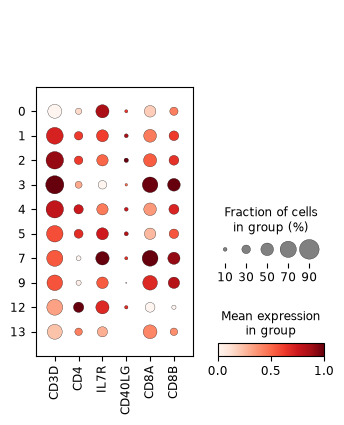

In [ ]:
#I am making another dot pot to check the T-cell subtypes in the clusters.
#tumour-infiltrating T cells are typically a healthy mix of CD4 and CD8. 
#Getting ~5 CD8 clusters, 34 Tregs, and essentially no CD4 helpers is not a plausible immune landscape 
#it's a sign the labels are wrong, not that the tumour is strange.


t_clusters = ["0","1","2","3","4","5","7","9","12","13"]
sub = adata[adata.obs["leiden_0.4"].isin(t_clusters)]

sc.pl.dotplot(sub, ["CD3D", "CD4", "IL7R", "CD40LG", "CD8A", "CD8B"],
              groupby="leiden_0.4", standard_scale="var", use_raw=True)

In [17]:
#a table showing how our 14 clusters at resolution 0.4 map onto the clusters at resolution 0.6

pd.crosstab(adata.obs["leiden_0.4"], adata.obs["leiden_0.6"])

leiden_0.6,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
leiden_0.4,,,,,,,,,,,,,,,,,,
0,203,434,0,0,0,1,48,0,0,0,0,0,9,7,0,0,0,0
1,123,727,107,205,496,62,0,0,0,0,0,0,5,1,0,0,0,0
2,0,5,0,0,17,347,0,0,0,0,0,0,0,0,0,0,0,0
3,266,17,760,22,122,23,1,0,0,360,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,30,0,0,0,0,0
5,4,7,1,0,0,30,0,30,0,0,0,0,0,0,1,0,0,0
6,0,0,0,0,0,0,0,96,0,0,0,333,0,0,0,0,0,0
7,0,1,0,0,0,0,1,16,0,0,0,0,0,148,0,0,0,0
8,0,0,0,0,0,0,0,0,82,0,0,0,0,0,0,0,0,0


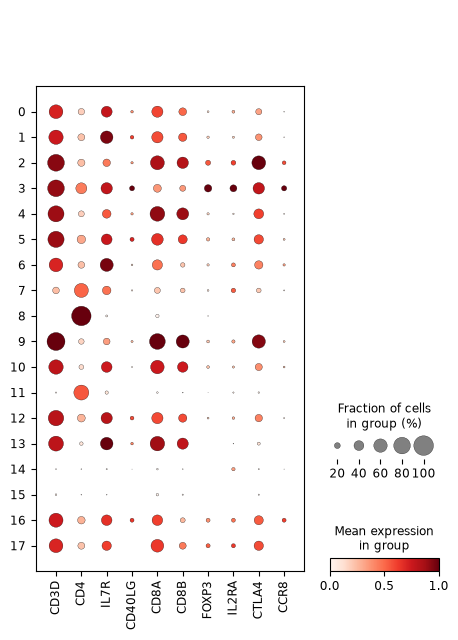

In [18]:
#does 0.6 give me a FOXP3+ cluster and a CD4 cluster that 0.4 didn't?
#yes to both - and because of this we will continue to use the 0.6 resolution for the rest of the analysis.

sc.pl.dotplot(adata, ["CD3D","CD4","IL7R","CD40LG","CD8A","CD8B","FOXP3","IL2RA","CTLA4","CCR8"],
              groupby="leiden_0.6", standard_scale="var", use_raw=True)

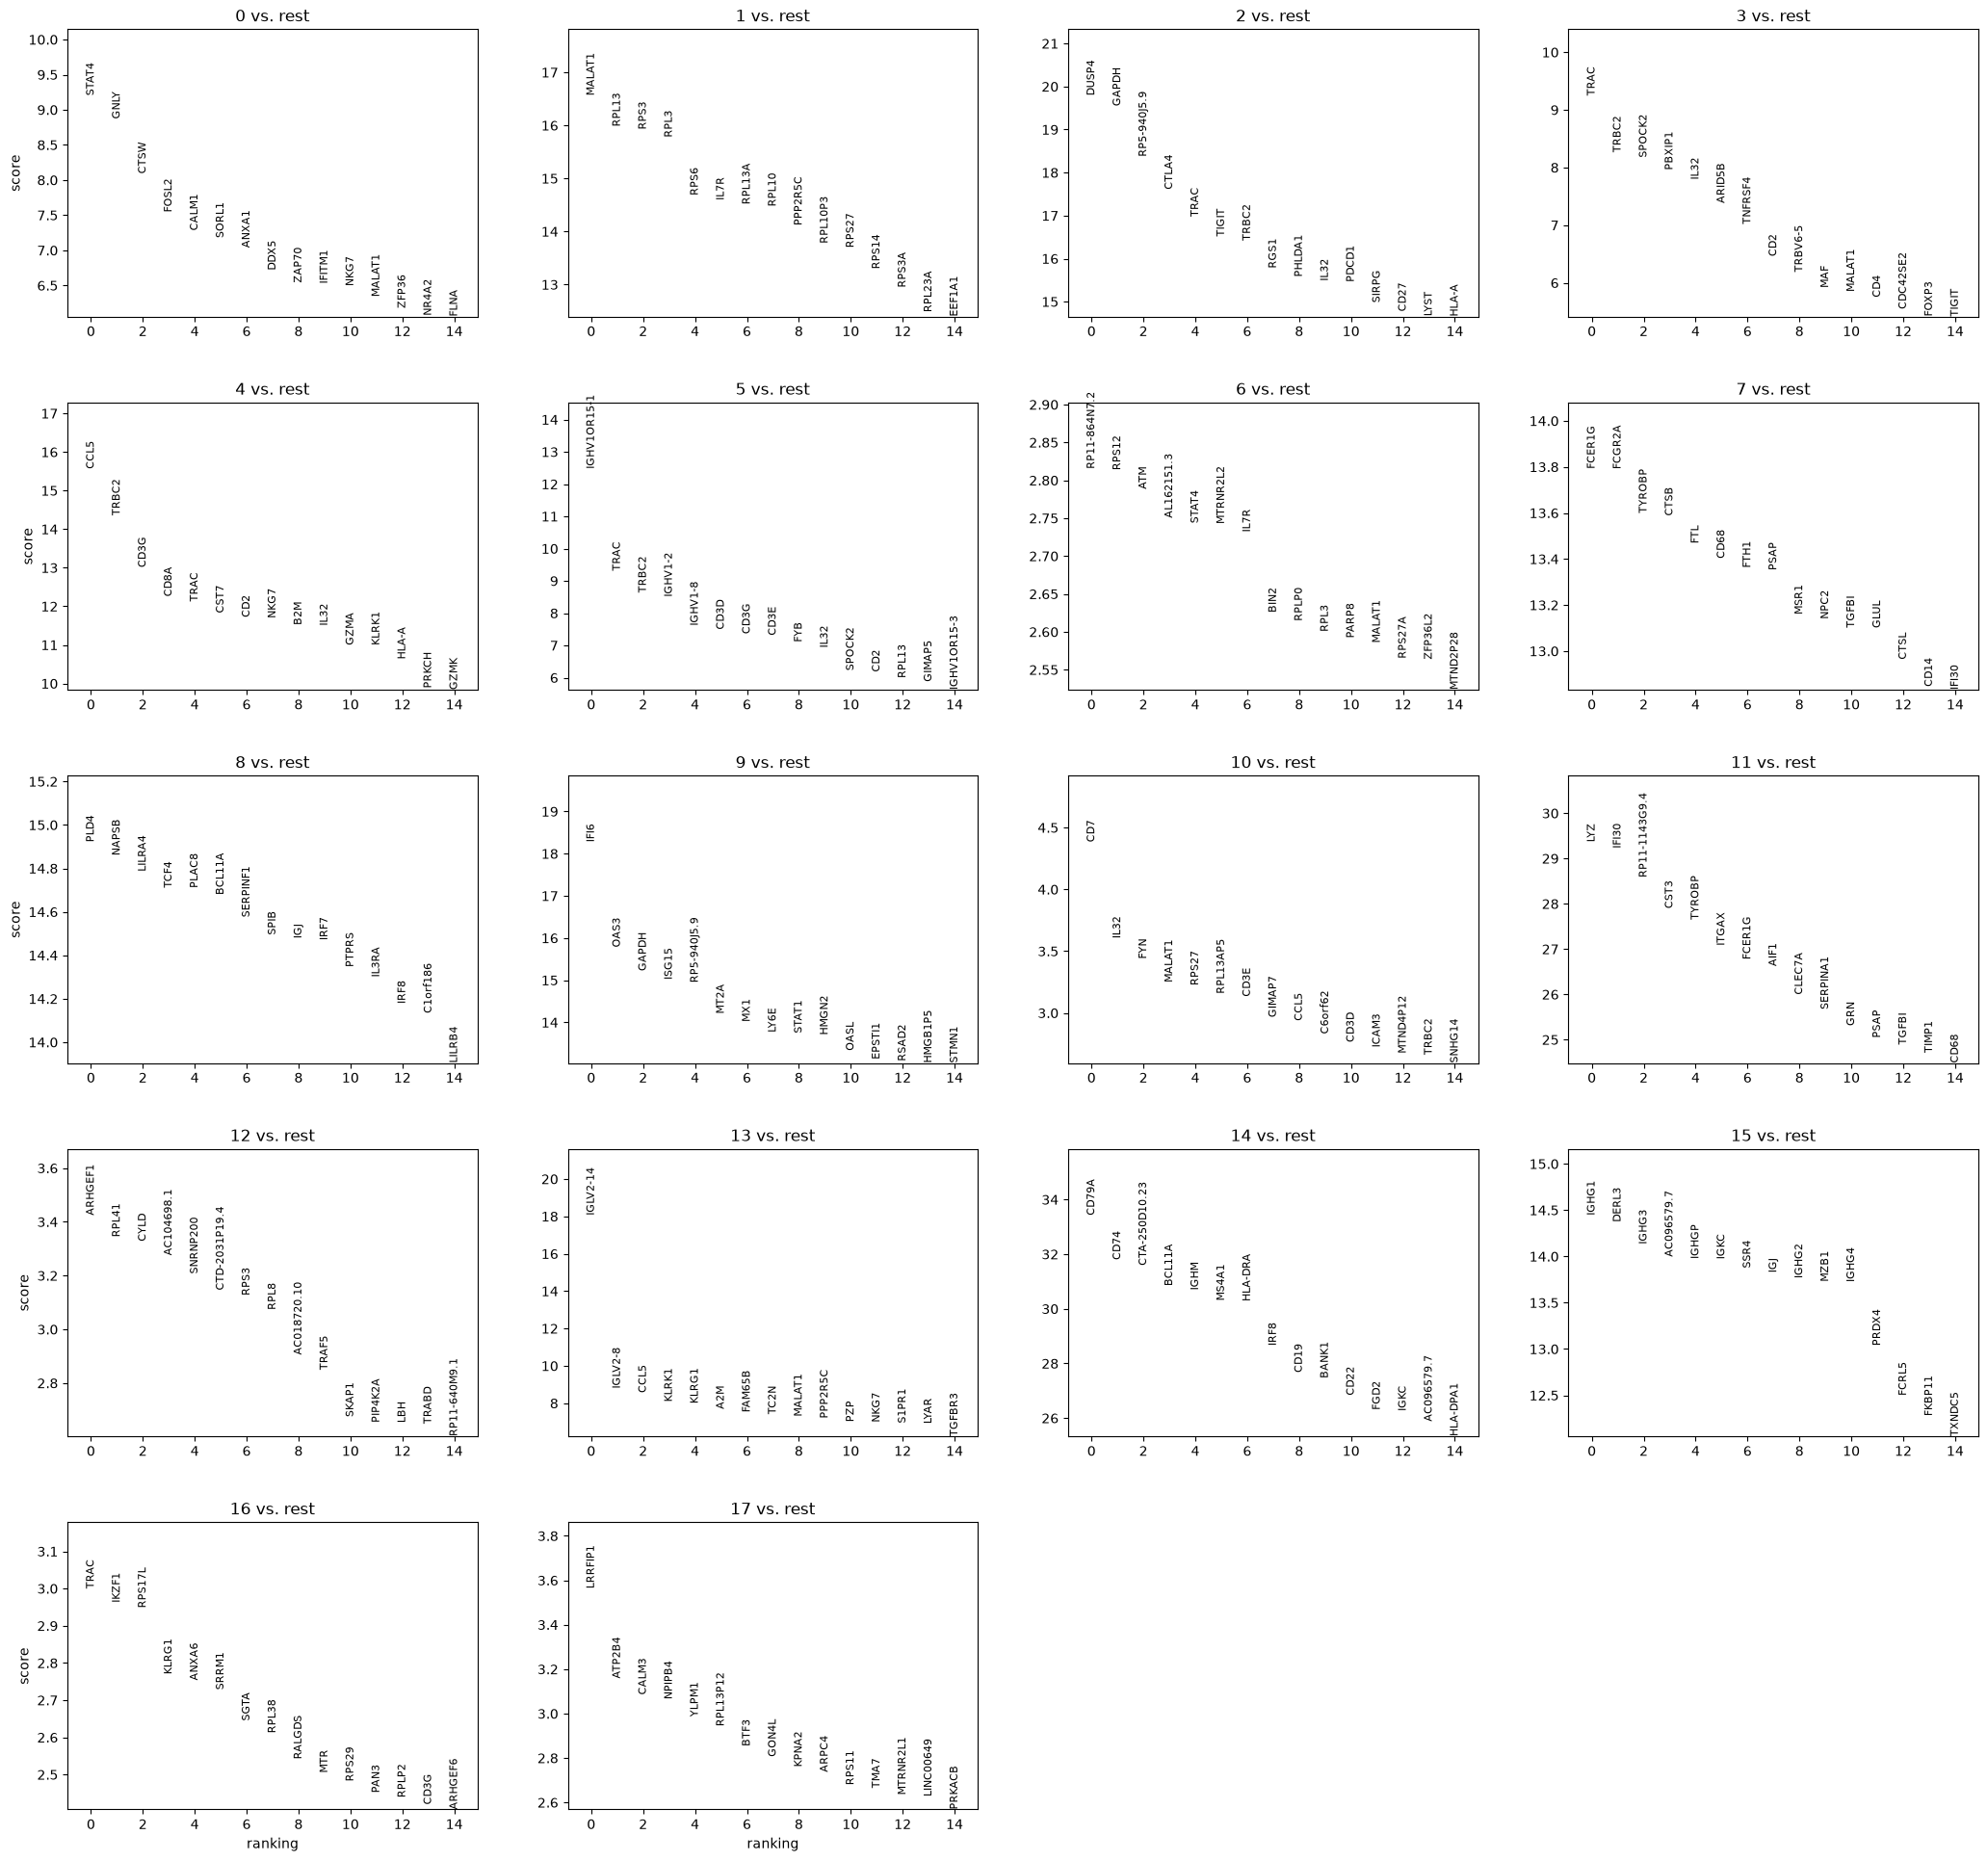

In [19]:
#Before we rebuild the mapping, we need to get the marker genes for the new clustering

sc.tl.rank_genes_groups(adata, "leiden_0.6", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=15, sharey=False)

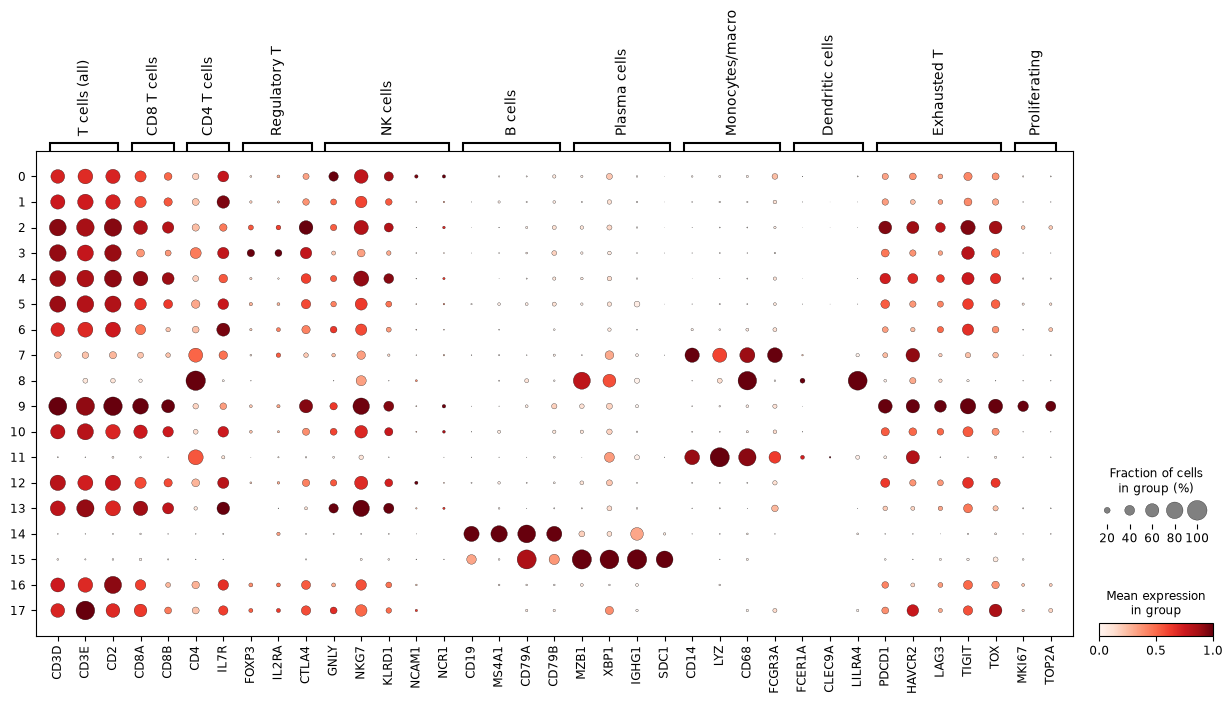

In [20]:
# Full marker cheat-sheet dotplot across all 18 clusters at leiden_0.6 
# checking which clusters are CD3D-negative (non-T), whether a FOXP3/IL2RA/CTLA4 Treg cluster is now resolved, 
# and whether any NK population appears.


sc.pl.dotplot(adata, marker_genes_in_data, groupby="leiden_0.6",
              standard_scale="var", use_raw=True)

In [23]:
#using CellTypist to predict the cell types in our dataset using the new clustering at resolution 0.6


predictions_adata = predictions.to_adata()
adata.obs["celltypist"] = predictions_adata.obs.loc[adata.obs.index, "majority_voting"]

pd.crosstab(adata.obs["leiden_0.6"], adata.obs["celltypist"]).idxmax(axis=1)

leiden_0.6
0     Tem/Trm cytotoxic T cells
1     Tem/Trm cytotoxic T cells
2     Tem/Trm cytotoxic T cells
3            Regulatory T cells
4     Tem/Trm cytotoxic T cells
5     Tem/Trm cytotoxic T cells
6     Tem/Trm cytotoxic T cells
7                   Macrophages
8                           pDC
9     Tem/Trm cytotoxic T cells
10    Tem/Trm cytotoxic T cells
11          Classical monocytes
12    Tem/Trm cytotoxic T cells
13    Tem/Trm cytotoxic T cells
14                Naive B cells
15                 Plasma cells
16           Regulatory T cells
17    Tem/Trm cytotoxic T cells
dtype: category
Categories (15, object): ['CD16+ NK cells', 'Classical monocytes', 'DC1', 'DC2', ..., 'Tem/Effector helper T cells', 'Tem/Temra cytotoxic T cells', 'Tem/Trm cytotoxic T cells', 'pDC']

In [ ]:
#i wanted to make a UMAP now but i needed to check that my code would map out the right thing. 
#at first this didn't work so i re-ran all cells and it worked.
#it shows me that its using the old mapping from the 0.4 resolution, so i will need to make a new mapping for the 0.6 resolution.
#next cell i will try fix this

adata.obs["cell_type"].value_counts()

cell_type
CD8 T cells                     2290
Exhausted CD8 T cells           1588
Memory CD8 T cells               702
B cells                          574
Monocytes/Macrophages            429
Cytotoxic CD8 T cells            166
Plasmacytoid dendritic cells      82
Plasma cells                      61
Regulatory T cells                34
Name: count, dtype: int64

In [ ]:
#These are confidence scores for the CellTypist predictions on particular unresolved clusters.

pd.crosstab(adata.obs["leiden_0.6"], adata.obs["celltypist"], normalize="index").round(2).loc[["6","0","1","5","10","12","16","17"]]

celltypist,CD16+ NK cells,Classical monocytes,DC1,DC2,Intermediate macrophages,Macrophages,Memory B cells,Naive B cells,Plasma cells,Regulatory T cells,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Temra cytotoxic T cells,Tem/Trm cytotoxic T cells,pDC
leiden_0.6,,,,,,,,,,,,,,,
6,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.02,0.98,0.0
0,0.12,0.0,0.0,0.0,0.0,0.03,0.0,0.0,0.0,0.07,0.00,0.04,0.10,0.63,0.0
1,0.03,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.09,0.09,0.00,0.13,0.65,0.0
5,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.16,0.00,0.00,0.00,0.83,0.0
10,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,1.00,0.0
12,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,1.00,0.0
16,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1.00,0.00,0.00,0.00,0.00,0.0
17,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,1.00,0.0


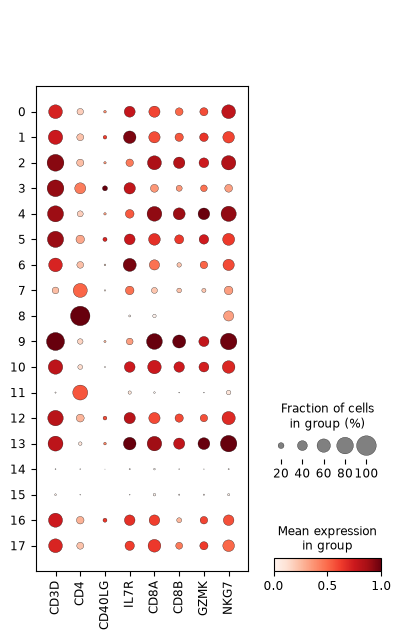

In [25]:
#CellTypist the markers and cell typist don't agree so we will make a dotplot to see if we can figure out what is going on with these clusters.

sc.pl.dotplot(adata, ["CD3D","CD4","CD40LG","IL7R","CD8A","CD8B","GZMK","NKG7"],
              groupby="leiden_0.6", standard_scale="var", use_raw=True)

In [ ]:
#mapping our new predicitons to the clusters at resolution 0.6.


mapping_06 = {
    "0":  "T cells",                       # both methods split — honest broad label
    "1":  "T cells",                       # both methods split
    "2":  "Exhausted CD8 T cells",
    "3":  "Regulatory T cells",            # markers + CellTypist agree
    "4":  "Cytotoxic CD8 T cells",
    "5":  "CD8 T cells",                   # leans CD8, CellTypist 83%
    "6":  "Memory T cells",                # IL7R-high, lineage unclear
    "7":  "Monocytes/Macrophages",
    "8":  "Plasmacytoid dendritic cells",
    "9":  "Exhausted CD8 T cells",         # + proliferating (MKI67/TOP2A)
    "10": "CD8 T cells",                   # CD8B solid, CellTypist 100%
    "11": "Monocytes/Macrophages",
    "12": "CD8 T cells",                   # CD8B solid, CellTypist 100%
    "13": "Cytotoxic CD8 T cells",
    "14": "B cells",
    "15": "Plasma cells",
    "16": "Regulatory T cells",            # both methods agree — 2nd Treg cluster
    "17": "T cells",                       # CD8B weak, lineage unclear
}

adata.obs["cell_type"] = adata.obs["leiden_0.6"].map(mapping_06).astype("category")
adata.obs["cell_type"].value_counts()

cell_type
T cells                         1803
Exhausted CD8 T cells           1237
Cytotoxic CD8 T cells            792
CD8 T cells                      600
B cells                          560
Monocytes/Macrophages            475
Regulatory T cells               252
Plasmacytoid dendritic cells      82
Plasma cells                      75
Memory T cells                    50
Name: count, dtype: int64

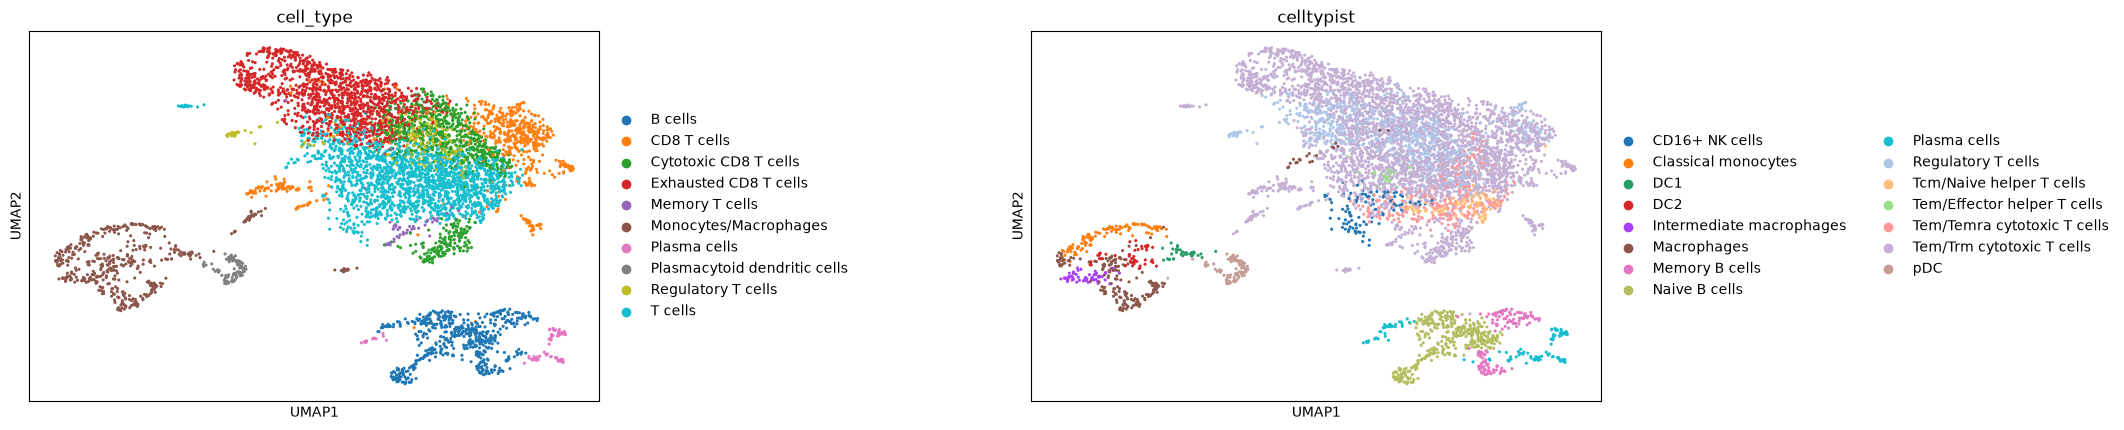

In [27]:
#making a UMAP to visualize the new mapping of cell types at resolution 0.6.

sc.pl.umap(adata, color=["cell_type", "celltypist"],
           legend_loc="right margin", wspace=0.6)

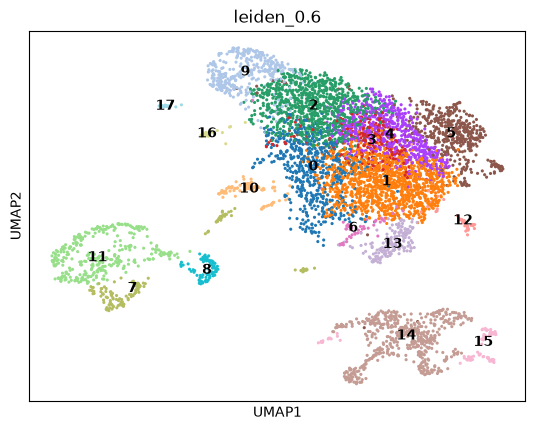

In [28]:
sc.pl.umap(adata, color="leiden_0.6", legend_loc="on data")

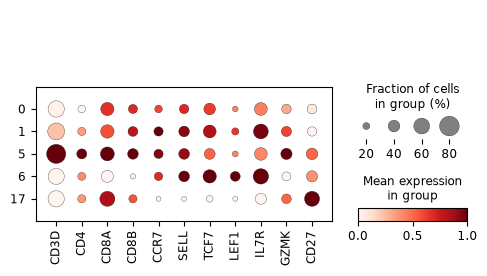

In [ ]:
#The memory T cell cluster is too small so we will try check for additional markers to see if we can resolve this better
#there is also a very large cluster of T cells that we will try and resolve.

t_bucket = ["0","1","5","6","17"]
sub = adata[adata.obs["leiden_0.6"].isin(t_bucket)]

sc.pl.dotplot(sub, ["CD3D","CD4","CD8A","CD8B","CCR7","SELL","TCF7","LEF1","IL7R","GZMK","CD27"],
              groupby="leiden_0.6", standard_scale="var", use_raw=True)

In [30]:
#i want to check and see if the 1.0 resolution seperates the big T-cell cluster on its own. 

pd.crosstab(adata.obs["leiden_0.6"], adata.obs["leiden_1.0"], normalize="index").round(2).loc[["0","1","5","6","17"]]

leiden_1.0,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
leiden_0.6,,,,,,,,,,,,,,,,,,,,,
0,0.37,0.00,0.00,0.00,0.09,0.13,0.05,0.00,0.00,0.33,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
1,0.01,0.37,0.34,0.01,0.00,0.00,0.00,0.03,0.00,0.06,...,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0
5,0.00,0.00,0.00,0.84,0.01,0.00,0.00,0.01,0.01,0.00,...,0.0,0.0,0.0,0.0,0.12,0.0,0.0,0.0,0.0,0.0
6,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
17,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1.0,0.0


In [ ]:
#i am now updating the mapping based on the new evidence 

mapping_06 = {
    "0":  "Naive/stem-like T cells",       # CCR7/SELL/TCF7/LEF1 — was "T cells"
    "1":  "Memory CD8 T cells",            # IL7R/GZMK — was "T cells"
    "2":  "Exhausted CD8 T cells",
    "3":  "Regulatory T cells",
    "4":  "Cytotoxic CD8 T cells",
    "5":  "CD8 T cells",
    "6":  "Memory CD8 T cells",            # IL7R/GZMK — merges with 1, 17
    "7":  "Monocytes/Macrophages",
    "8":  "Plasmacytoid dendritic cells",
    "9":  "Exhausted CD8 T cells",
    "10": "CD8 T cells",
    "11": "Monocytes/Macrophages",
    "12": "CD8 T cells",
    "13": "Cytotoxic CD8 T cells",
    "14": "B cells",
    "15": "Plasma cells",
    "16": "Regulatory T cells",
    "17": "Memory CD8 T cells",            # IL7R/GZMK — was "T cells"
}

adata.obs["cell_type"] = adata.obs["leiden_0.6"].map(mapping_06).astype("category")
adata.obs["cell_type"].value_counts()

cell_type
Memory CD8 T cells              1257
Exhausted CD8 T cells           1237
Cytotoxic CD8 T cells            792
CD8 T cells                      600
Naive/stem-like T cells          596
B cells                          560
Monocytes/Macrophages            475
Regulatory T cells               252
Plasmacytoid dendritic cells      82
Plasma cells                      75
Name: count, dtype: int64

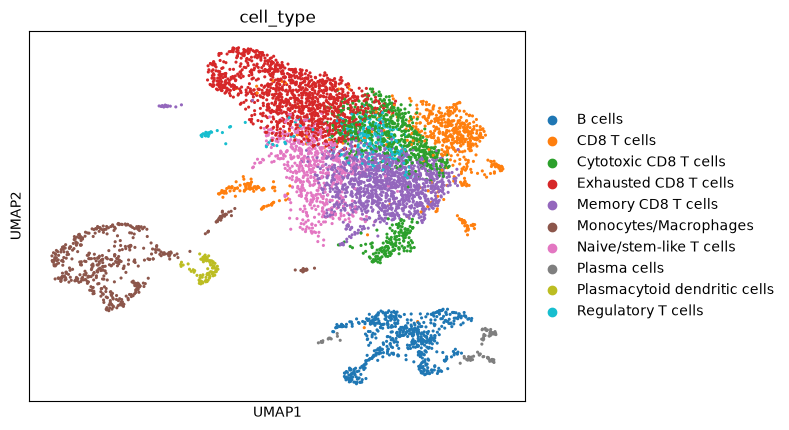

In [32]:
#and another new UMAP for the code above 

sc.pl.umap(adata, color="cell_type", legend_loc="right margin")

In [33]:
#comparing this with the CellTypist results

pd.crosstab(adata.obs["cell_type"], adata.obs["celltypist"])

celltypist,CD16+ NK cells,Classical monocytes,DC1,DC2,Intermediate macrophages,Macrophages,Memory B cells,Naive B cells,Plasma cells,Regulatory T cells,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Temra cytotoxic T cells,Tem/Trm cytotoxic T cells,pDC
cell_type,,,,,,,,,,,,,,,
B cells,0,0,0,0,0,0,136,375,48,0,0,0,0,1,0
CD8 T cells,0,0,0,0,0,0,0,1,0,75,1,0,0,523,0
Cytotoxic CD8 T cells,0,0,0,0,0,0,0,0,0,19,0,0,52,721,0
Exhausted CD8 T cells,0,0,0,0,0,3,0,0,0,305,0,0,0,929,0
Memory CD8 T cells,31,0,0,0,0,0,0,0,0,112,113,3,155,843,0
Monocytes/Macrophages,0,103,35,57,57,176,0,0,0,0,0,0,0,46,1
Naive/stem-like T cells,74,0,0,0,0,19,0,0,0,42,1,22,60,378,0
Plasma cells,0,0,0,0,0,0,0,0,75,0,0,0,0,0,0
Plasmacytoid dendritic cells,0,0,0,0,0,0,0,0,0,0,0,0,0,0,82


In [36]:
#last adjustment to the labels 

mapping_06["5"]  = "Cytotoxic CD8 T cells"
mapping_06["10"] = "Cytotoxic CD8 T cells"
mapping_06["12"] = "Cytotoxic CD8 T cells"

adata.obs["cell_type"] = adata.obs["leiden_0.6"].map(mapping_06).astype("category")
adata.obs["cell_type"].value_counts()

cell_type
Cytotoxic CD8 T cells           1392
Memory CD8 T cells              1257
Exhausted CD8 T cells           1237
Naive/stem-like T cells          596
B cells                          560
Monocytes/Macrophages            475
Regulatory T cells               252
Plasmacytoid dendritic cells      82
Plasma cells                      75
Name: count, dtype: int64

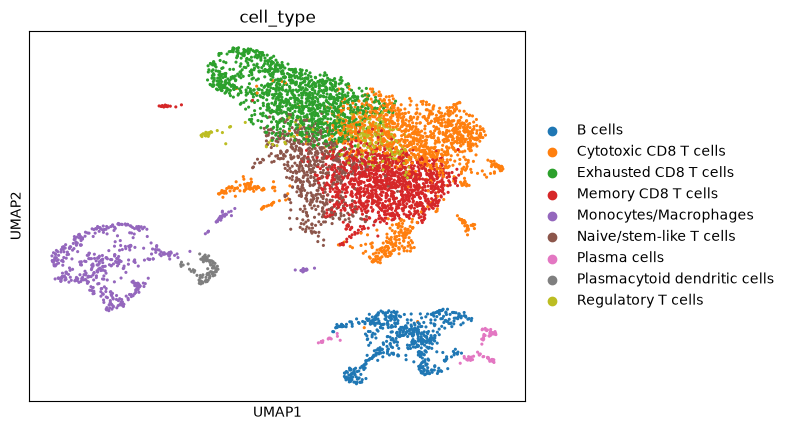

In [37]:
#making the last UMAP (i hope)

sc.pl.umap(adata, color="cell_type", legend_loc="right margin")

In [38]:
#saving this 

adata.write("baseline_annotated.h5ad")